This tutorial will go through creating a disk basis from a custom density function, computing coefficients from an input analytic density function, and computing some metrics for getting a sense of how well the basis is reconstructing the input density 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyEXP
import math

In [2]:
# we start out by making a python file for the disk density, which takes in cylindrical R, z, and phi
body = ("a = .1                     # Scale radius \n"
    "h = 0.0125                     # Scale height \n"
    "Rmax = 5.0*a                  # Maximum radius \n"
    "zmax = 8.0*h                  # Maximum height \n"
    "Rwid = 0.2*a                  # Rollover length \n"
    "zwid = 0.2*h                  # Rollover height \n"
    "f = math.erf( (R - Rmax)/Rwid ) \n"
    "g = math.erf( (math.fabs(z) - zmax)/zwid ) \n"
    "return (1.0 - f)*(1.0 - g)*0.25")

with open(f'pydensfile.py', 'w') as f:
    f.write("import math\n\n")
    f.write(f"# lozenge disk density -- this is fat in r and z \n")
    f.write(f"def disk_density(R, z, phi):\n")
    # indent body lines by 4 spaces
    for line in body.splitlines():
        f.write("    " + line + "\n")
    f.write("\n")
    f.close()

In [3]:
# now we define our basis yaml file

##the pcavar. subsamp, totalCovar, and fullCovar are all specified so that we can compute signal to noise of the coefficients later
disk_config = """
---
id: cylinder
parameters:
  acyl: 0.1       # for python dtype, acyl, hcyl help define coord transform instead of being the actual scale height or length
  hcyl: 0.0125      # for python dtype, acyl, hcyl help define coord transform instead of being the actual scale height or length 
  lmaxfid: 24      # The maximum spherical harmonic order for the input basis ---- this is LOW to run on laptop
  nmaxfid: 16      # The radial order for the input spherical basis ---- this is LOW to run on laptop
  mmax: 4          # The maximum azimuthal order for the cylindrical basis -- also low 
  nmax: 12         # The maximum radial order of the cylindrical basis -- also low
  ncylnx: 128      # The number of grid points in mapped cylindrical radius - low
  ncylny: 64      # The number of grid points in mapped verical scale - low
  ncylodd: 2       # The number of anti-symmetric radial basis functions per azimuthal order m
  rnum: 1000       # The number of radial integration knots in the inner product
  pnum: 0          # The number of azimuthal integration knots (pnum: 0, assume axisymmetric target density)
  tnum: 80         # The number of colatitute integration knots
  ashift: 0.5      # Target shift length in scale lengths to create more variance
  vflag: 16        # Verbosity flag: print diagnostics to stdout for vflag>0
  logr: false      # Log scaling in cylindrical radius
  dtype: python    # Use user-supplied python module
  pyname: pydensfile   # The module name
  pcavar: true       # turn on covariance
  subsamp: 100    #number of subsamples
  totalCovar: true   #compute total covariance
  fullCovar: true    #compute covariance per subsample
  cachename: lozenge_pydensfile  # The cache file name
...
"""
#while this _does_ run on a laptop, it takes a few minutes -- patience is a virtue
disk_basis = pyEXP.basis.Basis.factory(disk_config)

---- Cylindrical: using original exponential deprojected disk for EOF conditioning
---- Cylindrical: consider using the exact, spherically deprojected exponential with 'mtype: ExpSphere'
---- EmpCylSL::ReadH5Cache: read <lozenge_pydensfile>
---- EmpCylSL::read_cache: table forwarded to all processes
---- Cylindrical::orthoTest: worst=0.00136691


Worker    0: tables allocated, MMAX=4


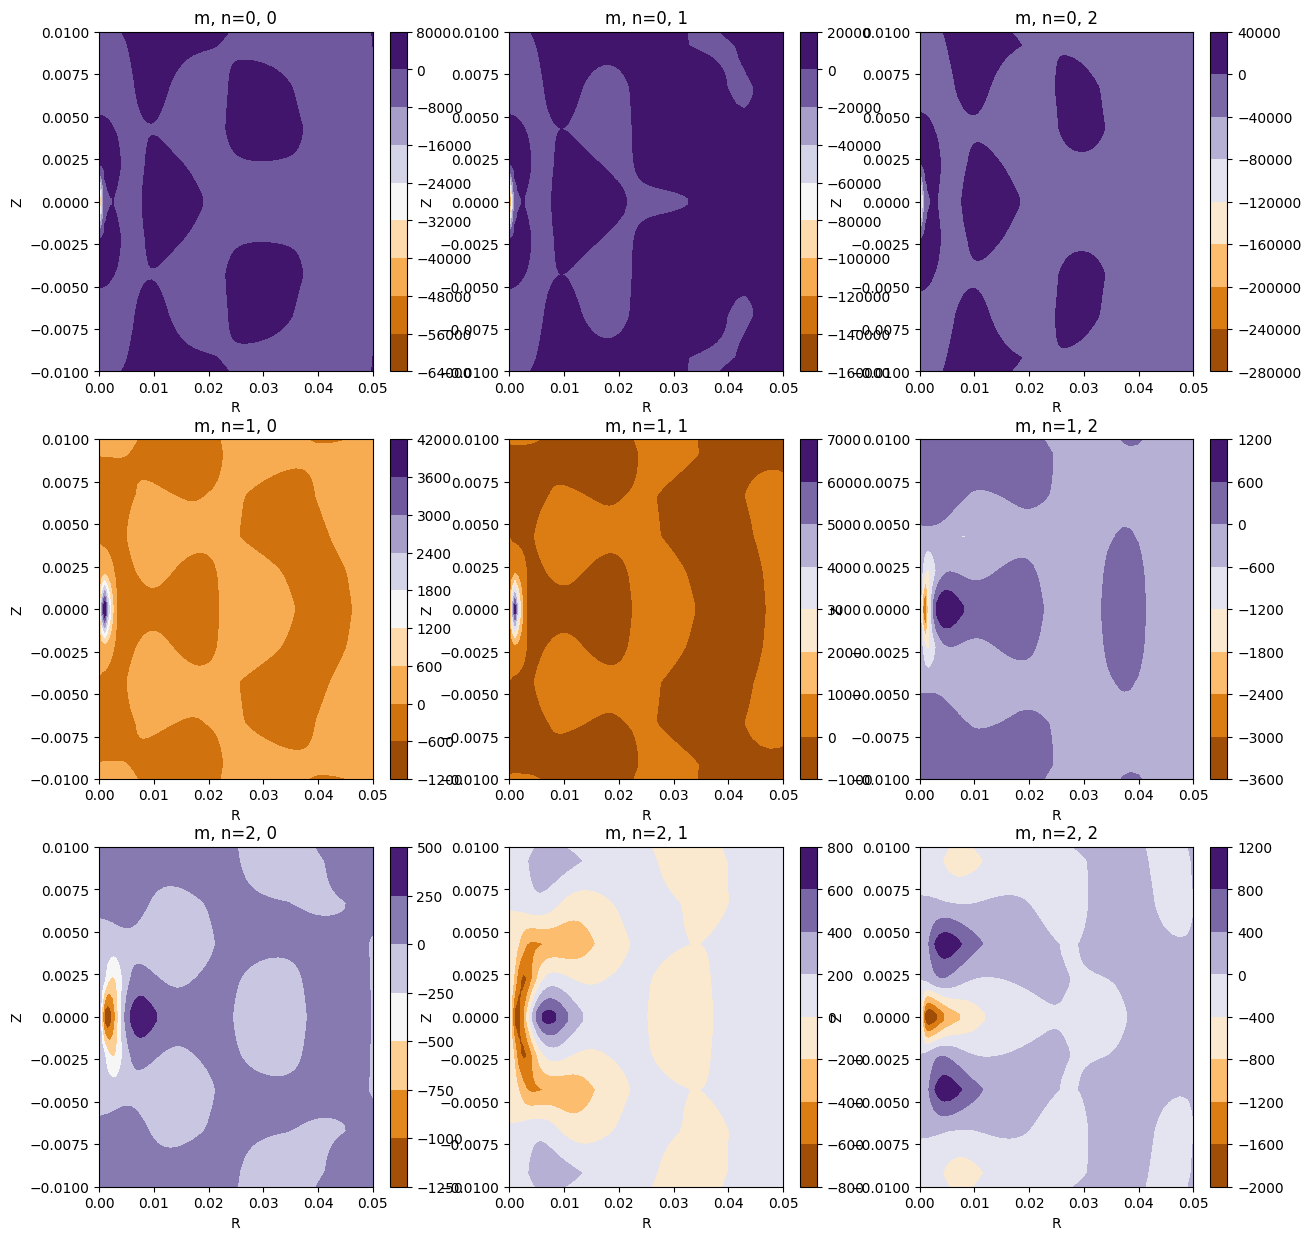

In [4]:
#lets take a look at this basis! pretty zoomed in here
Rmin = 0.0
Rmax = 0.05
Rnum = 100
Zmin = -0.01
Zmax =  0.01
Znum = 50
R = np.linspace(Rmin, Rmax, Rnum)
Z = np.linspace(Zmin, Zmax, Znum)

xv, yv = np.meshgrid(R, Z)

disk_grid = disk_basis.getBasis(Rmin, Rmax, Rnum, Zmin, Zmax, Znum)

fig, ax = plt.subplots(3, 3, figsize=(15, 15))
for m in range(3):
    for n in range(3):
        # Tranpose for contourf
        cx = ax[m][n].contourf(xv, yv, disk_grid[m][n]['density'].transpose(), cmap='PuOr')
        ax[m][n].set_xlabel('R')
        ax[m][n].set_ylabel('Z')
        ax[m][n].set_title('m, n={}, {}'.format(m, n))
        fig.colorbar(cx, ax=ax[m][n])


In [9]:
# define the analytic density function for which we want to get coefficients
# lets just do an exponential disk density
def disk_density(x, y, z, t):
    R = math.sqrt(x*x + y*y)
    a = 0.01                   # Scale radius
    h = 0.002                     # Scale height
    f = math.exp(-R/a)
    g = math.exp(-2*math.fabs(z)/h)
    return f * g/(1 + g)**2 /( np.pi*a*a*h/2 )

#get the coefficients for the disk density function - 0.0 here is the time, anything in the curly brackets are parameters passed to
#the basis, here we pass number of knots
coef = disk_basis.makeFromFunction(disk_density, {'knots': 200}, 0.0)
coefs = pyEXP.coefs.Coefs.makecoefs(coef)
coefs.add(coef)
data = coefs.getAllCoefs()
power = coefs.Power()
disk_basis.set_coefs(coef) ### this part is critical!! will NOT just get picked up otherwise, unlike the particle data below


Text(0.5, 1.0, 'Power in m for disk_density')

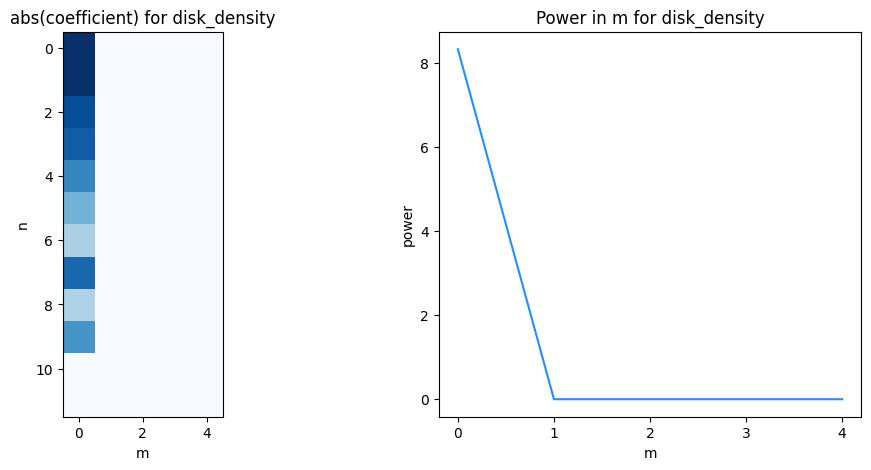

In [10]:
#lets plot coefficient info
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.imshow(abs(data.T)[0,:,:], cmap='Blues')
ax1.set_xlabel('m')
ax1.set_ylabel('n')
ax1.set_title('abs(coefficient) for disk_density')

ax2.plot(power[0,:], c='dodgerblue')
ax2.set_xticks(np.arange(0, 5, 1))
ax2.set_xlabel('m')
ax2.set_ylabel('power')
ax2.set_title('Power in m for disk_density')


Now we compute the mean integrated square error between the basis and our analytic function. We also include code for how to compute the MISE for a distribution of particles (like as in a simulation)

In [11]:
# Compute the mean-integrated-square-error integrand between the analytic and basis 
def MISE(x, y, z):
    a, b = disk_basis(x, y, z)
    val = disk_density(x, y, z, 0)
    return (val + a[2]*np.pi*4)*(val + a[2]*np.pi*4)

mse = disk_basis.computeQuadrature(MISE, {'knots': 80})
print('Mean Integrated Square Error for disk_density: ', mse)

#what if we tried a different scale height & scale length?


def disk_density_alt(x, y, z, t):
    R = math.sqrt(x*x + y*y)
    a = 0.1                   # Scale radius
    h = 0.0125                     # Scale height
    f = math.exp(-R/a)
    g = math.exp(-2*math.fabs(z)/h)
    return f * g/(1 + g)**2 /( np.pi*a*a*h/2 )

def MISE(x, y, z):
    a, b = disk_basis(x, y, z)
    val = disk_density_alt(x, y, z, 0)
    return (val + a[2]*np.pi*4)*(val + a[2]*np.pi*4)

mse = disk_basis.computeQuadrature(MISE, {'knots': 80})
print('Mean Integrated Square Error for disk_density_alt: ', mse)
#note that the alternative disk density has scale height/radius closer to the basis, and has smaller MSE as anticipated

Mean Integrated Square Error for disk_density:  227885.81239256138
Mean Integrated Square Error for disk_density_alt:  5278.4608790999855


# computing some metrics from particle data. Here we use one of the snapshot outputs created in the Tutorials/EXP/disk halo.ipynb notebook

In [19]:
#exp phase space reader - feed in type of file, list of snapshots, 0 for no mpi, and then verbose flag
#file types: PSPout PSPspl GadgetNative GadgetHDF5 PSPhdf5 TipsyNative TipsyXDR Bonsai1 Bonsai
reader = pyEXP.read.ParticleReader.createReader('PSPout', ['/mnt/home/cfilion/basis_explore/pyEXP-examples/Tutorials/Data/OUT.run0.00014'], 0, True)
disk_basis = pyEXP.basis.Basis.factory(disk_config)

---- Cylindrical: using original exponential deprojected disk for EOF conditioning
---- Cylindrical: consider using the exact, spherically deprojected exponential with 'mtype: ExpSphere'
---- EmpCylSL::ReadH5Cache: read <lozenge_pydensfile>
---- EmpCylSL::read_cache: table forwarded to all processes
---- Cylindrical::orthoTest: worst=0.00136691


Worker    0: tables allocated, MMAX=4


In [20]:
#set up an iterator to get the particle position information, you could revise to include mass etc
#here we also print out the index, mass, and position of the first few particles
reader.GetTypes()
#we want star particles in the disk
reader.SelectType('star disk')
all_pos = []
#define our function, here we just append to a list defined out of the function
def return_particles(mass, pos, vel, index):
    if index<=5:
        print('index, mass, x, y, z =', index, mass, pos[0], pos[1], pos[2])
    all_pos.append(list(pos))
    return 
#and now we run it - pos_data is our final numpy array of positions
pyEXP.util.particleIterator(reader, return_particles)
pos_data = np.array(all_pos)

index, mass, x, y, z = 1 2.499999936844688e-06 -0.024796808138489723 -0.020248208194971085 0.0005109473131597042
index, mass, x, y, z = 2 2.499999936844688e-06 -0.003697120351716876 -0.0013143334072083235 -0.0003451256488915533
index, mass, x, y, z = 3 2.499999936844688e-06 -0.009376737289130688 0.0032472845632582903 0.0009379141265526414
index, mass, x, y, z = 4 2.499999936844688e-06 -0.012227064929902554 0.007487384602427483 -0.0005084450822323561
index, mass, x, y, z = 5 2.499999936844688e-06 -0.003187113208696246 -0.0060020205564796925 -0.0022160853259265423


(-0.1, 0.1)

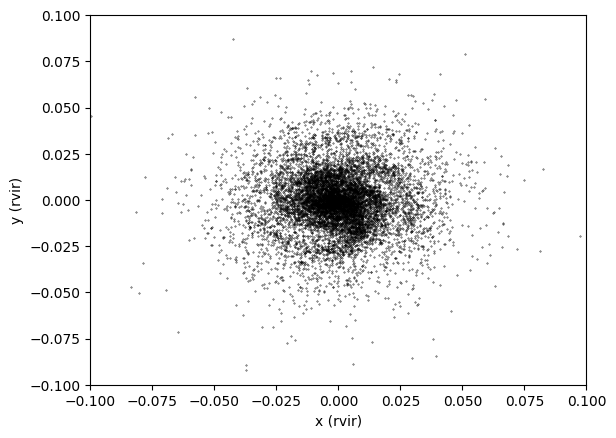

In [21]:
#lets plot to see what it looks like
plt.scatter(pos_data[:,0], pos_data[:,1], c='k', s=.1)
plt.xlabel('x (rvir)')
plt.ylabel('y (rvir)')
plt.ylim(-.1, .1)
plt.xlim(-.1, .1)

In [22]:
#EXP provides a nice particle-based KDE, we can use this to get density estimates from the data
#assuming equal mass particles that sum to 1, so mass = 1/N - can of course read in mass info too etc
kddens = pyEXP.util.KDdensity(mass = 1/pos_data.shape[0]*np.ones(pos_data.shape[0]), 
                             pos = pos_data, Ndens = 16)

---- KDdensity: finished density estimate with 0 undetermined densities, mass=1
---- KDdensity: a few densities are 54694.4, 112126, 5288.08
---- KDdensity: bad density count is 0 of 10000 particles.


In [23]:
#lets make coefficients from this distribution -
empirical_coef = disk_basis.createFromArray(1/pos_data.shape[0]*np.ones(pos_data.shape[0]), 
                                pos_data, time=0.0)
empirical_coefs = pyEXP.coefs.Coefs.makecoefs(empirical_coef, 'halo')

empirical_coefs.add(empirical_coef)
empirical_coefs.setUnits([('length', 'none', 1),
                                            ('mass', 'none', 1),
                                            ('time', 'none', 1),
                                            ('G', 'none', 1)])

SubsampleCovariance: reading basis type Cylindrical


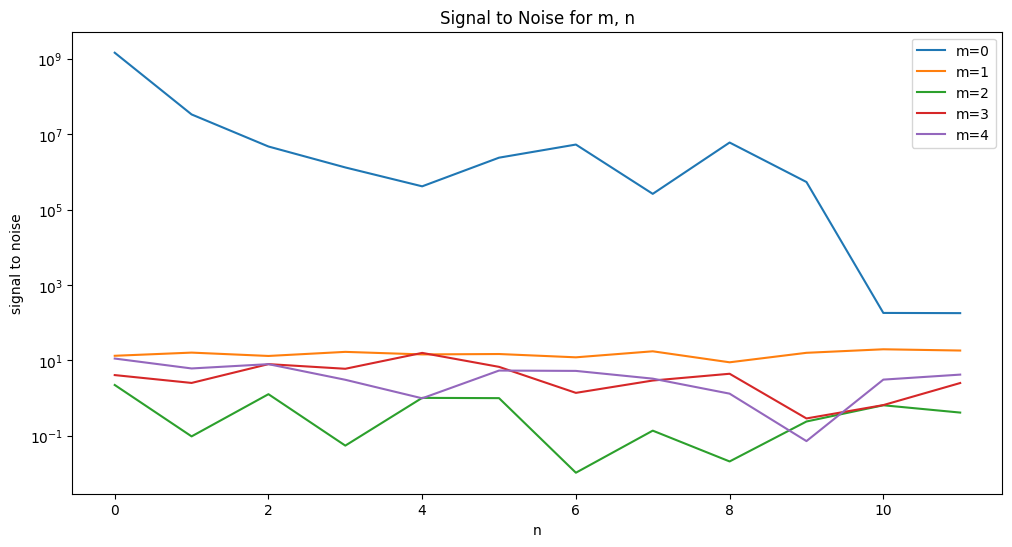

In [24]:
#now lets compute the signal to noise of the coefficients
disk_basis.enableCoefCovariance(True, 100) #turning on coefcovariance with 100 subsamples
disk_basis.writeCoefCovariance('star','tutorial_covar', 0.0) #what component, name for saving out, and timestep
covar = pyEXP.basis.CovarianceReader('coefcovar.star.tutorial_covar.h5') #reading in the covariance file we just wrote out
counts, masses, coefs_cov, covrs = covar.getCoefCovariance(0.0) #and getting covariance at 0.0

mmax = 4
nmax = 12
nsamp = counts.shape[0]
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
for m in range(mmax+1):
    sumCoef = np.zeros((nmax), dtype=np.complex128)
    for T in range(nsamp):
        sumCoef += coefs_cov[T, m, :]
    sumCoef /= nsamp
    varmat=np.zeros((nmax, nsamp), dtype=np.complex128)
    for T in range(nsamp):
        varmat[:, T] = coefs_cov[T, m, :]
    val = np.cov(varmat)
    sn = np.zeros(val.shape[0])
    sig = np.zeros(val.shape[0])
    for i in range(val.shape[0]):
        sn[i] = np.abs(sumCoef[i])**2 * nsamp / np.abs(val[i, i])
        sig[i] = np.abs(sumCoef[i])**2 * nsamp
    ax.semilogy(sn, label='m='+str(m))
ax.set_xlabel('n')
ax.set_ylabel('signal to noise')
ax.set_title('Signal to Noise for m, n')
ax.legend()

In [36]:
#now we can use this density to compute the MISE using the particle data as follows, using our basis from above:

def fullMISE(dat, disk_basis, disk_kde):
    MISE = 0.0
    for i in range(len(dat[:,0])):
        a, b = disk_basis(dat[i, 0], dat[i, 1], dat[i, 2])
        d = disk_kde.getDensityAtPoint(dat[i, 0], dat[i, 1], dat[i, 2]) + 4*np.pi*a[2]
        MISE += d*d
    return MISE/len(dat[:,0])

#is this missing a mass factor somewhere?
print('full MISE for all disk particles: ', fullMISE(pos_data, disk_basis, kddens))

full MISE for all disk particles:  145210702562.49203
